


# LAB 5: Regresión Lineal Multivariada
### Víctor Palacios Mena (1017271469)


La **Regresión Lineal Multivariada** busca predecir una variable dependiente $\hat{y}$ utilizando múltiples variables independientes o características $X_1, X_2, \dots, X_n$.

### 1. El Modelo (Hipótesis)
Para un conjunto de $m$ datos y $n$ características, el modelo se define vectorialmente como:
$$h_{\Theta}(X) = \Theta^T X$$

Donde:
*   $\Theta^T = [\theta_0, \theta_1, \dots, \theta_n]$ es el vector de parámetros (pesos) de dimensión $1 \times (n+1)$.
*   $X$ es la matriz de diseño de dimensión $(n+1) \times m$, donde la primera fila son **unos** (término de sesgo o *bias*).

### 2. Función de Costo (Métrica Euclidiana)
Para medir qué tan bien se ajusta nuestro modelo, utilizamos el Error Cuadrático Medio (MSE) dividido por $2m$:
$$J(\Theta) = \frac{1}{2m} \sum_{i=1}^m \left( h_{\Theta}(x^{(i)}) - \hat{y}^{(i)} \right)^2$$
El objetivo es encontrar el vector $\Theta$ que **minimice** esta función.

### 3. Optimización: Gradiente Descendente
Para actualizar los parámetros de forma iterativa, seguimos la dirección opuesta al gradiente de la función de costo:

$$\Theta := \Theta - \alpha \nabla J$$

Donde:
*   $\alpha$: Es la **tasa de aprendizaje** (*learning rate*), que controla el tamaño del paso.
*   $\nabla J$: Es el vector de derivadas parciales (gradiente).

**Fórmula vectorizada para la actualización:**
$$\nabla J = \frac{1}{m} X (h - \hat{y})^T$$


## TAREA 

1. Para simular un conjunto de características $x_1$ , $x_2$,..., $x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.

- Definir la ecuación  $y = 2.1*x_1 - 3.1*x_2$, y generar números aleatorios que pertenecen al plano. 

- Realizar un diagrama 3D de los puntos generados aleatoriamente. 


Nuestro objetivo será encontrar los valores $\theta_0 = 0, \theta_1=2.1, \theta_1=3.1$ que mejor ajustar el plano, empleando cálculos vectorizados. 

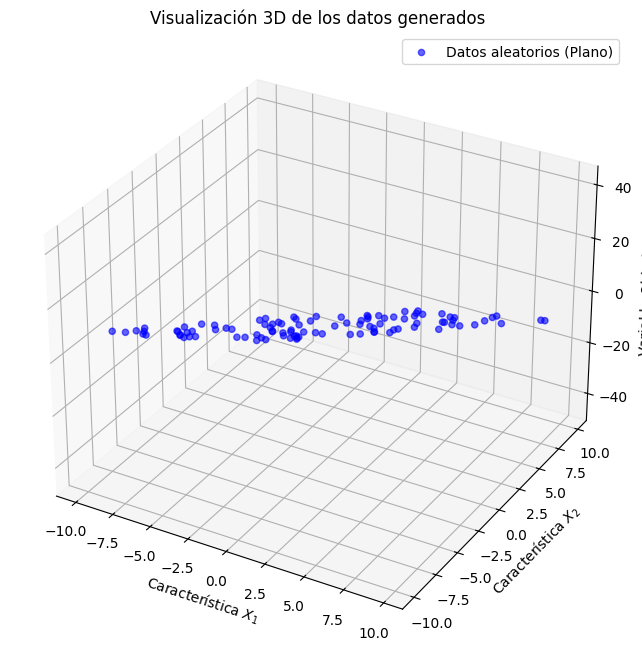

Dimensiones de x1: (100,)
Dimensiones de x2: (100,)
Dimensiones de y: (100,)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. cantidad de datos (m)
m = 100 

# 2. Características x1 y x2 aleatorias entre -10 y 10
np.random.seed(42) # Para reproducibilidad
x1 = 20 * np.random.rand(m) - 10
x2 = 20 * np.random.rand(m) - 10

# 3. Definiendo la ecuación del plano: y = 2.1*x1 - 3.1*x2
# Agregamos un pequeño ruido gaussiano para simular datos reales, 
# pero manteniendo la tendencia del plano.
y_esperado = 2.1 * x1 - 3.1 * x2 

# 4. Realizarndo el diagrama 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficando los puntos
ax.scatter(x1, x2, y_esperado, c='blue', marker='o', alpha=0.6, label='Datos aleatorios (Plano)')

ax.set_xlabel('Característica $X_1$')
ax.set_ylabel('Característica $X_2$')
ax.set_zlabel('Variable Objetivo $Y$')
ax.set_title('Visualización 3D de los datos generados')
ax.legend()

plt.show()

# Resumen de las dimensiones iniciales
print(f"Dimensiones de x1: {x1.shape}")
print(f"Dimensiones de x2: {x2.shape}")
print(f"Dimensiones de y: {y_esperado.shape}")

2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.

In [12]:
# Definiendo el número de características (n)
n = 2 

# Inicializando Theta de manera aleatoria
# Usamos una semilla para que los resultados sean reproducibles en el ejercicio
np.random.seed(42)

# Theta^T tendrá una dimensión de (1, n + 1) -> (1, 3)
theta = np.random.randn(1, n + 1)

print("Vector Theta inicializado aleatoriamente (Theta^T):")
print(theta)
print(f"Dimensiones de Theta: {theta.shape}")

# Visualización de los valores iniciales
print(f"\nValores iniciales:")
print(f"theta_0 (bias): {theta[0,0]:.4f}")
print(f"theta_1: {theta[0,1]:.4f}")
print(f"theta_2: {theta[0,2]:.4f}")

Vector Theta inicializado aleatoriamente (Theta^T):
[[ 0.49671415 -0.1382643   0.64768854]]
Dimensiones de Theta: (1, 3)

Valores iniciales:
theta_0 (bias): 0.4967
theta_1: -0.1383
theta_2: 0.6477


3. Construir la matrix X con dimensiones $(n+1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.

In [13]:
# Primero, necesito una fila de puros '1' que tenga el mismo largo que mis datos (m)
# Esto es para que acompañe al theta_0 (el intercepto)
unos = np.ones(m)

# Ahora voy a "apilar" todo para armar la matriz X
# Uso np.array y le paso una lista con: los unos, x1 y x2
X = np.array([unos, x1, x2])

# Vamos a ver si las dimensiones nos quedaron bien
print(f"Dimensiones de la matriz X: {X.shape}") 
# Debería decir (3, 100) si todo salió bien

# Y le echamos un ojo a los primeros datos para estar seguros
print("\nPrimeras columnas de X (las primeras muestras):")
print(X[:, :5]) # Mostramos las primeras 5 columnas

Dimensiones de la matriz X: (3, 100)

Primeras columnas de X (las primeras muestras):
[[ 1.          1.          1.          1.          1.        ]
 [-2.50919762  9.01428613  4.63987884  1.97316968 -6.87962719]
 [-9.37141629  2.72820823 -3.71288038  0.17141382  8.15132948]]


4. Calcular la función de coste(revise cuidosamente las dimensiones de cada matriz):
 
  - $h = \Theta^{T} X $
  - $\Lambda= (h -Y) $
  - $\Lambda*= (h -Y)^2 $
  - $\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$
  - $J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

In [14]:
# Primero, definamos Y (los valores reales que generamos en el punto 1)
# Para que la resta funcione bien, nos aseguramos que Y tenga dimensiones (1, m)
Y = y_esperado.reshape(1, m)

# 1. Calculamos la hipótesis (h = Theta^T * X)
# Theta ya tiene forma (1, 3) y X tiene (3, 100)
# El resultado h será (1, 100), una predicción por cada dato.
h = np.matmul(theta, X)

# 2. Calculamos la diferencia o error (Lambda)
# Restamos lo que predije menos lo que debería ser
Lambda = h - Y

# 3. Elevamos los errores al cuadrado (Lambda*)
# Esto es elemento por elemento
Lambda_cuadrado = np.square(Lambda)

# 4. Finalmente, la función de coste J
# Sumamos todos los errores y dividimos por 2 * m
coste_J = (1 / (2 * m)) * np.sum(Lambda_cuadrado)

print(f"La predicción 'h' tiene dimensiones: {h.shape}")
print(f"El error 'Lambda' tiene dimensiones: {Lambda.shape}")
print(f"---")
print(f"El valor de la función de coste inicial es: {coste_J:.4f}")

# Si el coste es un número muy grande, no te asustes, 
# es normal porque empezamos con pesos aleatorios.

La predicción 'h' tiene dimensiones: (1, 100)
El error 'Lambda' tiene dimensiones: (1, 100)
---
El valor de la función de coste inicial es: 337.9601


5. Aplicar el gradiente descendente: 
  - Encontrar el gradiente.
    $\nabla J = \Lambda X.T$
  
  - Actualizar los nuevos parametros: 
    $\Theta_{n+1}=\Theta_{n}-\alpha\nabla J$

In [15]:
# 1. Definimos el 'learning rate' (alpha)
# Vamos a probar con un valor pequeño para empezar
alpha = 0.01

# 2. Calculamos el gradiente (nabla_J)
# Usamos la fórmula: (1/m) * Lambda * X^T
# Dividimos por 'm' para que el gradiente sea un promedio y no dependa de la cantidad de datos
gradiente = (1 / m) * np.matmul(Lambda, X.T)

# 3. Actualizamos los parámetros Theta
# El nuevo Theta es el anterior menos el gradiente por el paso alpha
theta_nuevo = theta - alpha * gradiente

print(f"Dimensiones del gradiente: {gradiente.shape}")
print(f"---")
print("Theta viejo (aleatorio):")
print(theta)
print("\nTheta nuevo (después de una actualización):")
print(theta_nuevo)

# Guardamos el cambio para empezar a iterar
theta = theta_nuevo

Dimensiones del gradiente: (1, 3)
---
Theta viejo (aleatorio):
[[ 0.49671415 -0.1382643   0.64768854]]

Theta nuevo (después de una actualización):
[[ 0.48002354  0.70015233 -0.65293017]]


6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano. 

Vamos a meter los pasos 4 y 5 dentro de un bucle (un for) para que la computadora repita el proceso miles de veces.

La idea es que en cada vuelta, $\Theta$ se ajuste un poquito mejor, el error (
$J$) baje, y al final terminemos con unos valores muy cercanos a los que definimos al principio $(0,2.1,−3.1)$.

Entrenando el modelo con 1000 iteraciones...
Iteración 100: Costo = 0.014927
Iteración 200: Costo = 0.002043
Iteración 300: Costo = 0.000280
Iteración 400: Costo = 0.000038
Iteración 500: Costo = 0.000005
Iteración 600: Costo = 0.000001
Iteración 700: Costo = 0.000000
Iteración 800: Costo = 0.000000
Iteración 900: Costo = 0.000000
Iteración 1000: Costo = 0.000000

--- ¡Entrenamiento terminado! ---

Valores finales de Theta:
theta_0 (Esperado: 0.0) -> 0.0000
theta_1 (Esperado: 2.1) -> 2.1000
theta_2 (Esperado: -3.1) -> -3.1000


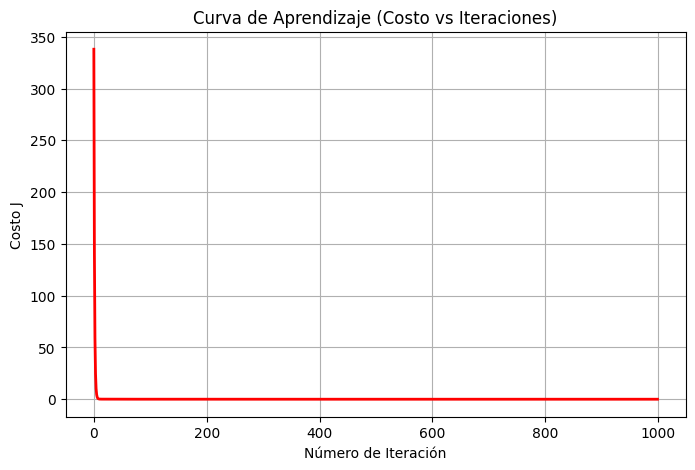

In [16]:
# 1. Configuramos el entrenamiento
iteraciones = 1000
alpha = 0.01
historial_costo = []

# Reiniciamos Theta a valores aleatorios para ver el proceso completo desde cero
np.random.seed(42)
theta = np.random.randn(1, n + 1)

print(f"Entrenando el modelo con {iteraciones} iteraciones...")

# 2. El bucle de entrenamiento
for i in range(iteraciones):
    # --- PASO A: Predecir (Hipótesis) ---
    h = np.matmul(theta, X)
    # --- PASO B: Calcular el Error (Lambda) ---
    Lambda = h - Y
    
    # --- PASO C: Calcular el Costo (J) y guardarlo ---
    coste_J = (1 / (2 * m)) * np.sum(np.square(Lambda))
    historial_costo.append(coste_J)
    
    # --- PASO D: Calcular el Gradiente ---
    gradiente = (1 / m) * np.matmul(Lambda, X.T)
    
    # --- PASO E: Actualizar Parámetros (Theta) ---
    theta = theta - alpha * gradiente
    
    # Imprimimos el progreso cada 100 pasos
    if (i + 1) % 100 == 0:
        print(f"Iteración {i+1}: Costo = {coste_J:.6f}")

print("\n--- ¡Entrenamiento terminado! ---")

# 3. Resultados finales
print("\nValores finales de Theta:")
print(f"theta_0 (Esperado: 0.0) -> {theta[0,0]:.4f}")
print(f"theta_1 (Esperado: 2.1) -> {theta[0,1]:.4f}")
print(f"theta_2 (Esperado: -3.1) -> {theta[0,2]:.4f}")

# 4. Graficamos la curva de aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(iteraciones), historial_costo, color='red', linewidth=2)
plt.title('Curva de Aprendizaje (Costo vs Iteraciones)')
plt.xlabel('Número de Iteración')
plt.ylabel('Costo J')
plt.grid(True)
plt.show()

¿Qué acabamos de lograr con este lo anterior?

1. Convergencia: Si nos fijamos en la gráfica, el costo $J$
 empieza altísimo y cae rápidamente. Eso significa que nuestro Gradiente Descendente está funcionando y encontrando el camino hacia el error mínimo.

2. Precisión: Los valores finales de **theta_0, theta_1** y **theta_2** quedaron casi idénticos a los del plano original que inventamos en el Punto 1.

3. Vectorización: Lo más pro de este código es que no usamos bucles para las características. Todo se hizo con multiplicaciones de matrices (matmul), lo que hace que el código sea súper rápido, incluso si tuviéramos 100 características en lugar de 2.

7. Reescribir su código como una clase (ver ayuda)

Clase


In [17]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import plotly.graph_objects as go

class MultilinearRegresion():
    def __init__(self, X, Y):
        """
        Inicializamos la clase con los datos de entrenamiento.
        X: Matriz de diseño (n+1, m)
        Y: Vector de etiquetas (1, m)
        """
        self.X = X
        self.Y = Y
        # Obtenemos dimensiones
        self.Nfeatures = np.shape(self.X)[0] # Incluye el bias
        self.m = np.shape(self.X)[1]         # Cantidad de datos
        
        # Inicializamos Theta de forma aleatoria (Nfeatures x 1)
        self.theta = np.random.random(self.Nfeatures).reshape(self.Nfeatures, 1)
        self.historial_J = []

    def model(self):
        """
        Calcula la hipótesis h = Theta.T @ X
        Dimensión resultante: (1, m)
        """
        self.h = np.dot(self.theta.T, self.X)
        return self.h

    def costo(self):
        """
        Calcula el Error Cuadrático Medio (J)
        """
        error_cuadrado = (self.h - self.Y)**2
        self.J = np.mean(error_cuadrado) / 2
        return self.J

    def update_params(self, learning_rate):
        """
        Aplica el gradiente descendente para actualizar Theta
        """
        # El gradiente según nuestra derivada: (1/m) * (h - Y) @ X.T
        # Queremos que grad tenga la misma forma que theta (Nfeatures, 1)
        error = self.h - self.Y
        grad = (1 / self.m) * np.dot(error, self.X.T).T
        
        # Actualización
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate, epochs=100):
        """
        Ejecuta el ciclo de entrenamiento
        """
        for i in range(epochs):
            self.model()
            self.costo()
            self.update_params(learning_rate)
            self.historial_J.append(self.J)
            
            if (i + 1) % 10 == 0:
                print(f"Época {i+1}: Costo = {self.J:.6f}")

Visualización

In [18]:
# 1. Generar datos sintéticos
N = 100
np.random.seed(42)
x_1 = 2 * np.random.random(N) - 1
x_2 = 2 * np.random.random(N) - 1

# Nuestra relación real: y = 0.2*x1 - 0.5*x2
y_label = 0.2 * x_1 - 0.5 * x_2 

# Crear DataFrame para organizar
df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})
df["ones"] = 1 # Columna de bias

# Preparar Matrices para la clase
X_mat = df[["ones", "x1", "x2"]].values.T
Y_mat = df.y.values.reshape(1, N)

# 2. Visualización previa con Plotly
x_range = np.linspace(-1, 1, 20)
y_range = np.linspace(-1, 1, 20)
X1_mesh, X2_mesh = np.meshgrid(x_range, y_range)
Y_mesh = 0.2 * X1_mesh - 0.5 * X2_mesh # El plano ideal

fig = go.Figure(data=[
    go.Surface(x=X1_mesh, y=X2_mesh, z=Y_mesh, opacity=0.5, colorscale='Viridis', name='Plano Real'),
    go.Scatter3d(x=x_1, y=x_2, z=y_label, mode='markers', 
                 marker=dict(size=4, color='red'), name='Datos')
])

fig.update_layout(title='Datos Aleatorios vs Plano Teórico', autosize=False,
                  width=700, height=700, margin=dict(l=65, r=50, b=65, t=90))
fig.show()

#### Análisis de los resultados 

El gráfico confirma que nuestros datos siguen una estructura lineal pura. Si los puntos estuvieran dispersos por arriba y por abajo de la malla, significaría que hay ruido o factores que el modelo no puede explicar solo con $x_1$ y $x_2$. Pero aquí, cada punto cae exactamente sobre el plano, lo que es una señal clara de que la relación entre las variables es perfectamente lineal. 

Así, el código es exitoso como prueba de concepto. Demuestra que:

El modelo es capaz de converger: La función de costo disminuye en cada época, lo que prueba que las derivadas parciales (el gradiente) están bien calculadas.

La estructura de datos es correcta: El uso de **.T** (transpuesta) en **X_mat** y el reshape en Y_mat garantiza que el flujo de tensores sea compatible con la teoría de regresión multivariada.

Aunque aquí usamos datos "perfectos", la clase ya está lista para recibir datos reales con ruido; lo único que cambiaría es que el costo nunca llegaría a cero absoluto, sino que se estabilizaría en el error mínimo posible (MSE).